In [1]:
cd ..

/Users/matthewshen/Desktop/drd


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import gc
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_wine, fetch_openml
import pandas as pd

from drd.drd import DRD

In [10]:
def load_datasets():
    wine_data = load_wine()
    X_wine = wine_data.data
    y_wine = wine_data.target

    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
    df_penguins = pd.read_csv(url).dropna()
    num_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
    cat_features = ["island", "sex"]
    df_penguins = pd.get_dummies(df_penguins, columns=cat_features)
    X_penguins = df_penguins[num_features + list(df_penguins.columns[-3:])]
    y_penguins = LabelEncoder().fit_transform(df_penguins["species"])

    mnist = fetch_openml('mnist_784', version=1)
    X_mnist = mnist.data[:30000]
    y_mnist = LabelEncoder().fit_transform(mnist.target[:30000])

    return {
        "wine": (X_wine, y_wine),
        "penguins": (X_penguins, y_penguins),
        "MNIST": (X_mnist, y_mnist)
    }

def run_experiment(X, y,dataset_name, lambda_values):
    results = []
    if dataset_name == 'MNIST':
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=(100/X.shape[0]), random_state=42)
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pca = PCA(n_components=2)
    X_teacher_train = pca.fit_transform(X_train)
    X_teacher_test = pca.transform(X_test)
    embeddings = {"PCA": (X_teacher_test, y_test)}

    for lambda_d in lambda_values:
        gc.collect()
        torch.cuda.empty_cache()

        student_model = DRD(input_dim=X.shape[1], latent_dim=2, epochs=50, batch_size=16 if X.shape[0] < 10000 else 128, lambda_d = lambda_d)  # Lowered batch size & epochs
        student_model.fit(X_train, teacher_Z = X_teacher_train)

        embeddings[f"DRD, λ={lambda_d}"] = (student_model.transform(X_test), y_test)

        X_train_reconstructed = student_model.inverse_transform(student_model.transform(X_train))
        student_embedding_train = student_model.transform(X_train)
        train_recon_loss = np.mean((X_train - X_train_reconstructed) ** 2)
        train_teacher_student_loss = np.mean((X_teacher_train - student_embedding_train) ** 2)

        X_test_reconstructed = student_model.inverse_transform(student_model.transform(X_test))
        student_embedding_test = student_model.transform(X_test)
        test_recon_loss = np.mean((X_test - X_test_reconstructed) ** 2)
        test_teacher_student_loss = np.mean((X_teacher_test - student_embedding_test) ** 2)

        results.append({
            "lambda_d": lambda_d,
            "train_reconstruction_loss": train_recon_loss,
            "test_reconstruction_loss": test_recon_loss,
            "train_teacher_student_loss": train_teacher_student_loss,
            "test_teacher_student_loss": test_teacher_student_loss
        })

    return pd.DataFrame(results), embeddings

lambda_values=[np.linspace(0, 0.025, 5), np.linspace(0, 0.005, 5), np.linspace(0, 0.00001, 5)]
datasets = load_datasets()
experiment_results = {}
dataset_embeddings = {}

for i, (dataset_name, (X, y)) in enumerate(datasets.items()):
    print(f"Running experiments for {dataset_name}...")
    results, embs = run_experiment(X, y, dataset_name, lambda_values[i])
    experiment_results[dataset_name] = results
    dataset_embeddings[dataset_name] = embs


Running experiments for wine...


100%|██████████| 50/50 [00:00<00:00, 299.43it/s]


Running experiments for penguins...


100%|██████████| 50/50 [00:00<00:00, 160.14it/s]


Running experiments for MNIST...


100%|██████████| 50/50 [00:23<00:00,  2.17it/s]


In [11]:
df

,lambda_d,train_reconstruction_loss,test_reconstruction_loss,train_teacher_student_loss,test_teacher_student_loss
0,0.0000,0.550681,0.512124,64.076346,215.978814
1,0.0125,0.588649,0.635911,3.236439,3.141524
2,0.0250,0.641392,0.681082,1.541014,1.283341
3,0.0375,0.656995,0.694005,0.837681,0.586055
4,0.0500,0.677544,0.721032,0.543904,0.359636


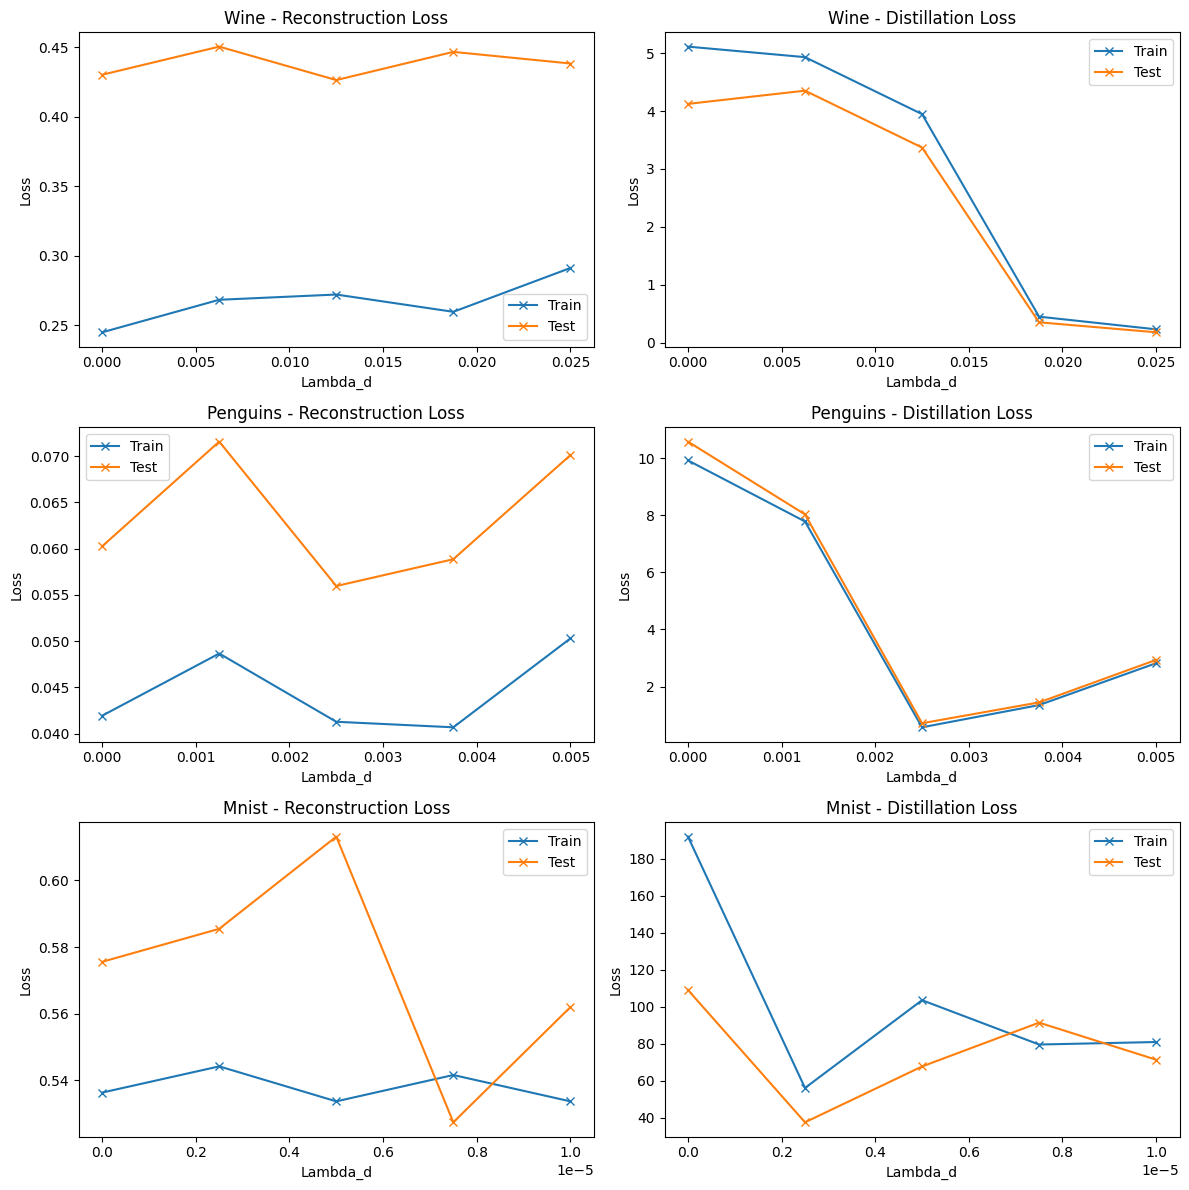

In [12]:

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, (dataset_name, df) in enumerate(experiment_results.items()):
    axes[2*i].plot(df["lambda_d"], df["train_reconstruction_loss"],  label="Train", marker='x')
    axes[2*i].plot(df["lambda_d"], df["test_reconstruction_loss"], label="Test", marker='x')
    axes[2*i].set_title(f"{dataset_name.capitalize()} - Reconstruction Loss")
    axes[2*i].set_xlabel("Lambda_d")
    axes[2*i].set_ylabel("Loss")
    axes[2*i].legend()

    axes[2*i+1].plot(df["lambda_d"], df["train_teacher_student_loss"], label="Train", marker='x')
    axes[2*i+1].plot(df["lambda_d"], df["test_teacher_student_loss"], label="Test", marker='x')
    axes[2*i + 1].set_title(f"{dataset_name.capitalize()} - Distillation Loss")
    axes[2*i + 1].set_xlabel("Lambda_d")
    axes[2*i + 1].set_ylabel("Loss")
    axes[2*i+1].legend()

plt.tight_layout()
plt.show()

PCA
0.025
0.018750000000000003
0.0125
0.00625
0.0


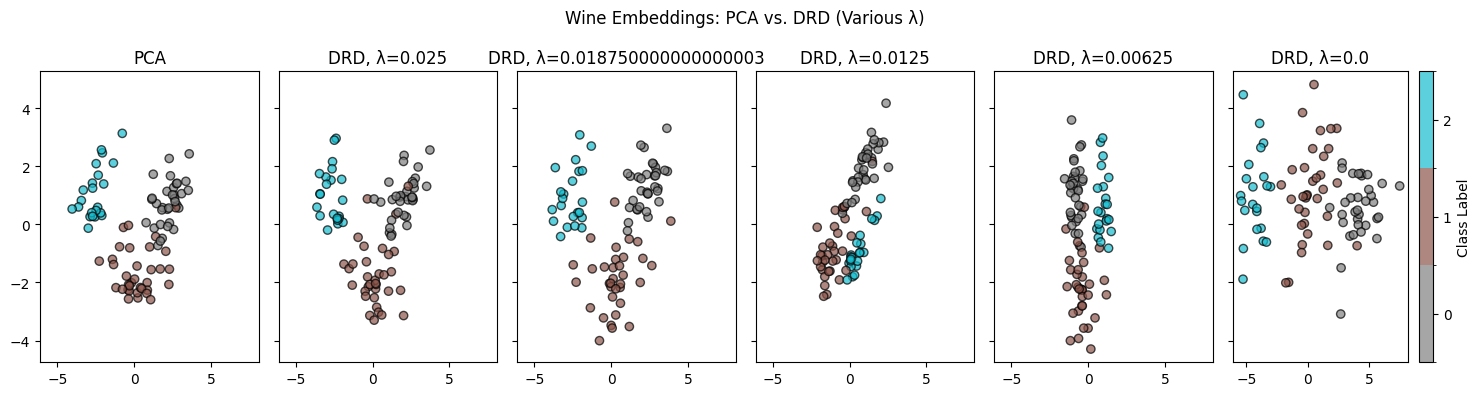

PCA
0.005
0.00375
0.0025
0.00125
0.0


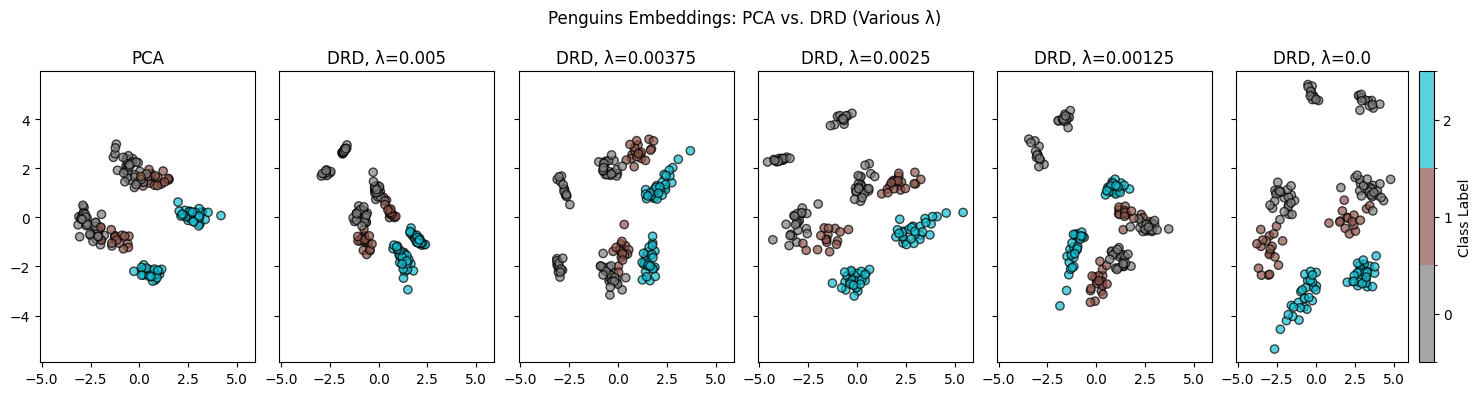

PCA
1e-05
7.500000000000001e-06
5e-06
2.5e-06
0.0


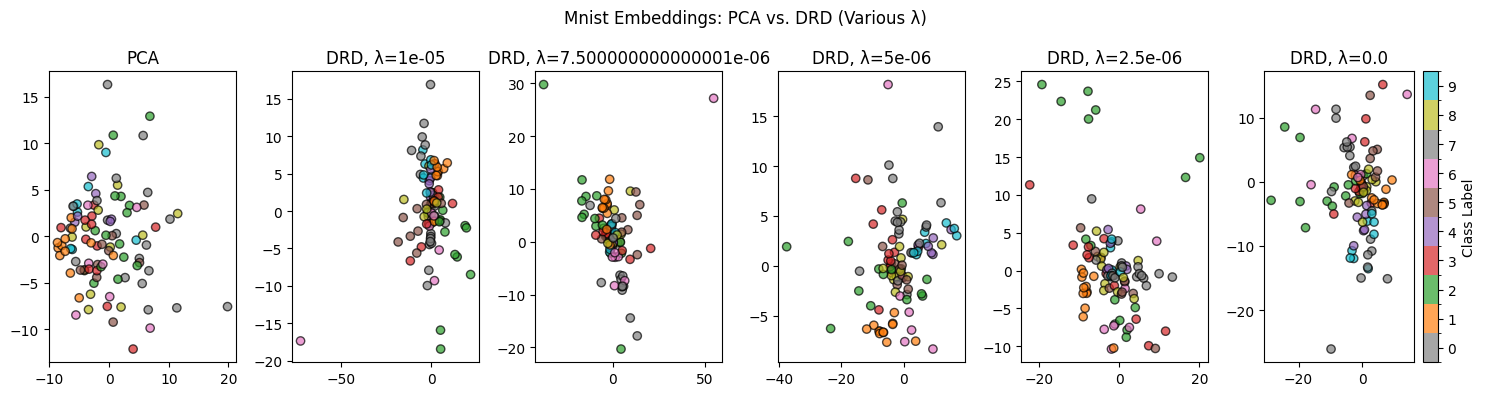

In [18]:

for i, (dataset_name, embeddings) in enumerate(dataset_embeddings.items()):
    y_embedded_sample = list(embeddings.values())[0][1]
    if isinstance(y_embedded_sample, pd.Series) and len(np.unique(y_embedded)) < 15:
        y_embedded_sample = y_embedded_sample.astype(str)
    label_encoder = LabelEncoder()
    y_embedded_sample = label_encoder.fit_transform(y_embedded_sample)
    num_classes = len(np.unique(y_embedded_sample))

    base_cmap = plt.colormaps["tab10"]  
    cmaplist = [base_cmap(i) for i in np.linspace(0, 1, num_classes)]
    cmaplist[0] = (0.5, 0.5, 0.5, 1.0)
    discrete_cmap = mpl.colors.ListedColormap(cmaplist)

    bounds = np.arange(num_classes + 1) - 0.5  
    norm = mpl.colors.BoundaryNorm(bounds, discrete_cmap.N)
    if dataset_name == 'MNIST':
        fig, axes = plt.subplots(1, len(lambda_values[i])+1, figsize=(15, 4), sharex=False, sharey=False)
    else:
        fig, axes = plt.subplots(1, len(lambda_values[i])+1, figsize=(15, 4), sharex=True, sharey=True)

    for i, key in enumerate(['PCA'] + list(lambda_values[i])[::-1]):
        print(key)
        if key != 'PCA':
            new_key = 'DRD, λ=' + str(key)
            X_embedded, y_embedded = embeddings[new_key]
        else:
            new_key = key
            X_embedded, y_embedded = embeddings[new_key]
        

        if isinstance(y_embedded, pd.Series) and len(np.unique(y_embedded)) < 15:
            y_embedded = y_embedded.astype(str)  

        y_embedded = label_encoder.transform(y_embedded) 

        scatter = axes[i].scatter(
            X_embedded[:, 0], X_embedded[:, 1], 
            c=y_embedded.astype(int),
            cmap=discrete_cmap, norm=norm, 
            alpha=0.7, edgecolor='k'
        )

        axes[i].set_title(new_key)

    cbar = fig.colorbar(scatter, ax=axes[-1], ticks=np.arange(num_classes))
    cbar.set_label("Class Label")
    cbar.set_ticks(np.arange(num_classes))  
    cbar.set_ticklabels(label_encoder.classes_ if 'label_encoder' in locals() else np.arange(num_classes))

    fig.suptitle(f"{dataset_name.capitalize()} Embeddings: PCA vs. DRD (Various λ)")
    plt.tight_layout()
    plt.show()
